# 0x11 Transformers

> ✨ **This notebook is co-authored with OpenAI Codex**

Transformers are sequence models built around one central operation: **attention**.

Instead of reading a sentence strictly left-to-right, a transformer repeatedly asks: **which earlier tokens should this token look at right now?**

In this notebook, we will:
- inspect how text becomes tokens,
- compute and plot attention matrices from a real transformer,
- use `Qwen/Qwen2.5-0.5B-Instruct` to generate text,
- peek at real model attention patterns.

In [1]:
# Setting up environment
import textwrap

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import Markdown, display
from transformers import AutoModelForCausalLM, AutoTokenizer

sns.set_theme(style="whitegrid")
torch.set_grad_enabled(False)


## 1. Text Becomes Tokens

A language model does not receive raw words.
It receives integer token IDs.

A token can be a whole word, part of a word, punctuation, whitespace, or a fragment from another writing system.

Modern LLM tokenizers are usually **subword tokenizers**, where words can be split into smaller chunks.

In [2]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

sample_text = "Transformers tokenize unbelievable words, emojis, and 中文 differently."
encoded = tokenizer(sample_text, return_offsets_mapping=True)
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"])

token_df = pd.DataFrame(
    {
        "token_id": encoded["input_ids"],
        "token": tokens,
        "text_span": [sample_text[start:end] for start, end in encoded["offset_mapping"]],
        "character_offsets": encoded["offset_mapping"],
    }
)
token_df


,token_id,token,text_span,character_offsets
0,8963,Transform,Transform,"(0, 9)"
1,388,ers,ers,"(9, 12)"
2,77651,Ġtokenize,tokenize,"(12, 21)"
3,51129,Ġunbelievable,unbelievable,"(21, 34)"
4,4244,Ġwords,words,"(34, 40)"
5,11,",",",","(40, 41)"
6,99066,Ġemojis,emojis,"(41, 48)"
7,11,",",",","(48, 49)"
8,323,Ġand,and,"(49, 53)"
9,72858,Ġä¸Ń,中,"(53, 55)"


The `token` column may contain special marker characters used internally by the tokenizer.
The `text_span` column is the part of the original string that produced each token.

In [3]:
phrases = [
    "cat",
    "unbelievable",
    "deep learning",
    "Deep learning",
    "transformer-based architecture",
    "I paid $19.99!",
]

rows = []
for phrase in phrases:
    ids = tokenizer.encode(phrase, add_special_tokens=False)
    rows.append(
        {
            "text": phrase,
            "num_tokens": len(ids),
            "token_ids": ids,
            "tokens": tokenizer.convert_ids_to_tokens(ids),
        }
    )

pd.DataFrame(rows)


,text,num_tokens,token_ids,tokens
0,cat,1,[4616],[cat]
1,unbelievable,3,"[359, 31798, 23760]","[un, belie, vable]"
2,deep learning,2,"[32880, 6832]","[deep, Ġlearning]"
3,Deep learning,2,"[33464, 6832]","[Deep, Ġlearning]"
4,transformer-based architecture,4,"[4701, 261, 5980, 17646]","[transform, er, -based, Ġarchitecture]"
5,I paid $19.99!,9,"[40, 7171, 400, 16, 24, 13, 24, 24, 0]","[I, Ġpaid, Ġ$, 1, 9, ., 9, 9, !]"


> 🤔 **THINKING**
>
> - Which examples became one token? Which examples were split?
> - Why might capitalization, punctuation, or language change the token count?

## 2. Load Qwen for Generation

Qwen is a family of models from Alibaba which is widely used in research as of the notebook is written (2026).

The next cells download and load `Qwen/Qwen2.5-0.5B-Instruct` from Hugging Face.
The first run may take some time.

> _The helper below tries the official `device_map="auto"` path first._
>
> _If the local environment does not have the optional acceleration package needed for that path, it falls back to a regular CPU/GPU load._

In [4]:
def load_qwen(model_name="Qwen/Qwen2.5-0.5B-Instruct", output_attentions=False):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model_kwargs = {"torch_dtype": "auto"}
    if output_attentions:
        model_kwargs["attn_implementation"] = "eager"

    try:
        model = AutoModelForCausalLM.from_pretrained(
            model_name,
            device_map="auto",
            **model_kwargs,
        )
    except Exception as exc:
        print(f"Falling back to manual device placement: {type(exc).__name__}: {exc}")
        device = "cuda" if torch.cuda.is_available() else "cpu"
        if device == "cpu":
            model_kwargs["torch_dtype"] = torch.float32
        model = AutoModelForCausalLM.from_pretrained(model_name, **model_kwargs)
        model = model.to(device)

    model.eval()
    return tokenizer, model


tokenizer, model = load_qwen(model_name)
model.device


Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


Falling back to manual device placement: ValueError: Using a `device_map` or `tp_plan` requires `accelerate`. You can install it with `pip install accelerate`


device(type='cpu')

Qwen Instruct models expect chat-style messages.
`apply_chat_template` turns a list of `{role, content}` messages into the exact text format expected by the model.

In [5]:
def generate_with_qwen(prompt, system_prompt="You are a helpful teaching assistant.", max_new_tokens=120):
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": prompt},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        pad_token_id=tokenizer.eos_token_id,
    )
    generated_ids = [
        output_ids[len(input_ids) :]
        for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids, strict=False)
    ]
    return tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]


response = generate_with_qwen("Give me a short introduction to transformer models.")
display(Markdown(response))


Transformers are a type of recurrent neural network (RNN) that have become very popular in natural language processing and other areas due to their ability to handle sequential data efficiently. They consist of multiple layers of transformations, each of which applies a set of linear transforms on the input sequence. The resulting output is often referred to as the "token embeddings" or "word embeddings." These embeddings allow the model to represent sequences of words or tokens more accurately than previous RNNs like LSTM or GRU. This makes them well-suited for tasks such as text generation, translation, and question answering.

> 📚 **EXERCISE**
>
> Change `your_prompt` and generate your own response.
> Try at least two prompts:
>
> - one factual prompt, such as `Explain attention in one paragraph.`
> - one creative prompt, such as `Write a haiku about matrix multiplication.`
>
> Then change `temperature` inside `generate_with_qwen` and observe how the style changes. What does this tell you about the role of temperature in generation?

In [6]:
your_prompt = "Explain why attention is useful for long sentences in three bullet points."
your_response = generate_with_qwen(your_prompt, max_new_tokens=160)
display(Markdown(your_response))


1. Attention helps to focus on the most important parts of a sentence.
2. It allows readers to easily distinguish between the main idea and supporting details, making it easier to understand complex information.
3. It enables writers to create more effective paragraphs and essays by providing structure and organization that enhances clarity and readability.

## 3. Inspect Real Attention

Now we ask the real model to return attention tensors.
For a causal language model, each layer returns a tensor shaped like:

`batch_size x num_heads x sequence_length x sequence_length`

The last two dimensions are the attention matrix we can plot. In a causal model, future positions are hidden (_why?_), but the model is still free to decide how much weight to place on the current token itself.

In [7]:
# Reload with eager attention if the current model was not loaded that way.
# This makes attention tensors available in recent transformer implementations.
del model
torch.cuda.empty_cache() if torch.cuda.is_available() else None
tokenizer, model = load_qwen(model_name, output_attentions=True)


Falling back to manual device placement: ValueError: Using a `device_map` or `tp_plan` requires `accelerate`. You can install it with `pip install accelerate`


Sliding Window Attention is enabled but not implemented for `eager`; unexpected results may be encountered.


In [8]:
# Prepare a sample input and get attention tensors from the model.
attention_text = "The cat sat on the mat because it was tired."
inputs = tokenizer(attention_text, return_tensors="pt").to(model.device)

outputs = model(**inputs, output_attentions=True, use_cache=False)
attentions = outputs.attentions

print(f"Number of layers with attention: {len(attentions)}")
print(f"One attention tensor shape: {tuple(attentions[0].shape)}")


Number of layers with attention: 24
One attention tensor shape: (1, 14, 11, 11)


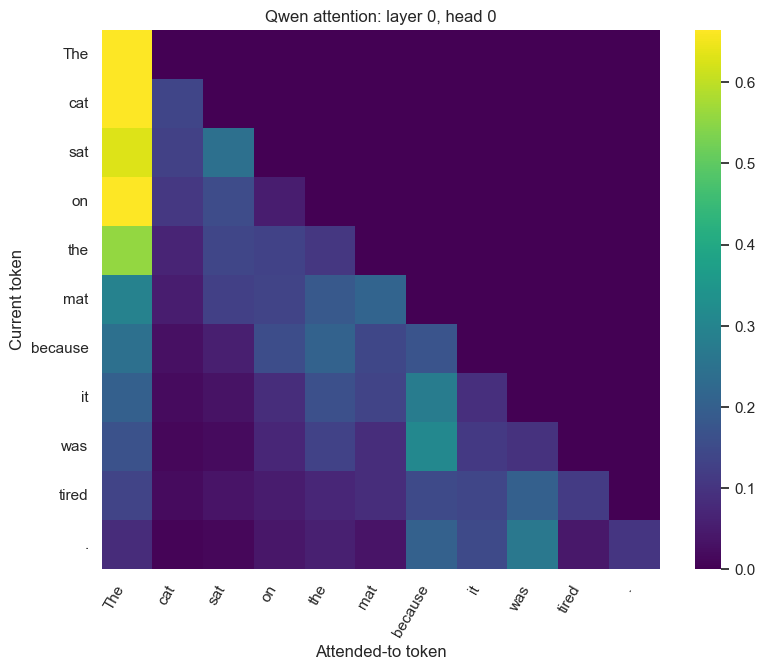

In [9]:
def compact_token_labels(tokenizer, input_ids, max_chars=14):
    labels = []
    for token_id in input_ids:
        text = tokenizer.decode([int(token_id)])
        text = text.replace("\n", "\\n")
        if text == " ":
            text = "<space>"
        labels.append(textwrap.shorten(text, width=max_chars, placeholder="..."))
    return labels


layer_idx = 0
head_idx = 0
real_attention = attentions[layer_idx][0, head_idx].detach().float().cpu().numpy()
labels = compact_token_labels(tokenizer, inputs.input_ids[0])

plt.figure(figsize=(9, 7))
sns.heatmap(
    real_attention,
    xticklabels=labels,
    yticklabels=labels,
    cmap="viridis",
    vmin=0,
    vmax=np.quantile(real_attention, 0.98),
)
plt.title(f"Qwen attention: layer {layer_idx}, head {head_idx}")
plt.xlabel("Attended-to token")
plt.ylabel("Current token")
plt.xticks(rotation=60, ha="right")
plt.yticks(rotation=0)
plt.show()


Different heads and layers can look very different.
Some heads focus strongly on nearby tokens, some attend to punctuation or role markers, and some spread attention more broadly.

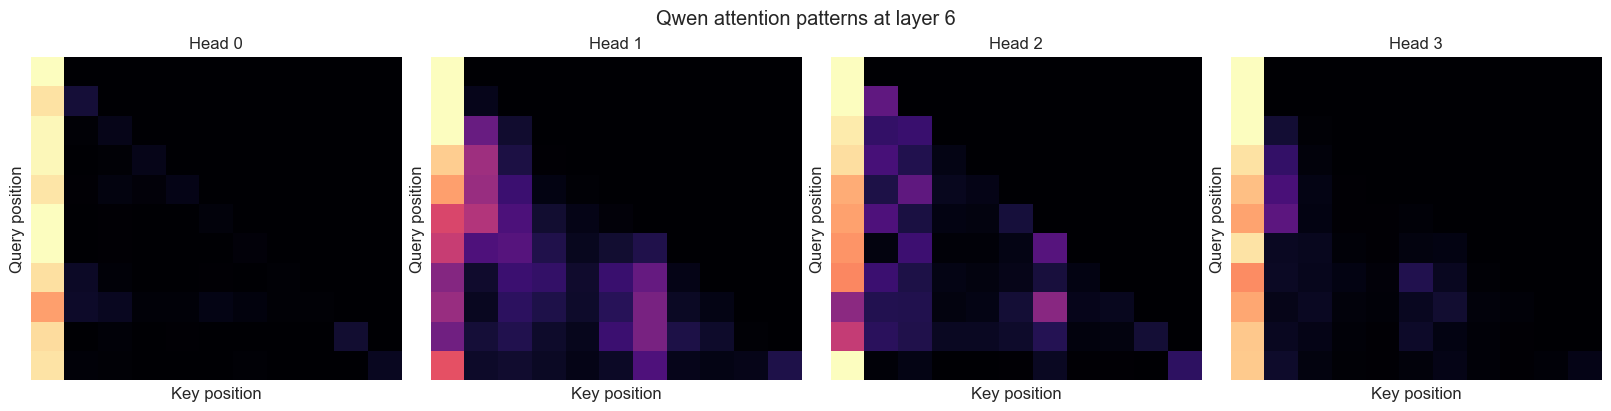

In [10]:
layer_idx = min(6, len(attentions) - 1)
num_heads = attentions[layer_idx].shape[1]
heads_to_plot = list(range(min(4, num_heads)))

fig, axes = plt.subplots(1, len(heads_to_plot), figsize=(4 * len(heads_to_plot), 4), constrained_layout=True)
if len(heads_to_plot) == 1:
    axes = [axes]

for ax, head_idx in zip(axes, heads_to_plot, strict=False):
    weights = attentions[layer_idx][0, head_idx].detach().float().cpu().numpy()
    sns.heatmap(
        weights,
        ax=ax,
        xticklabels=False,
        yticklabels=False,
        cmap="magma",
        cbar=False,
        vmin=0,
        vmax=np.quantile(weights, 0.98),
    )
    ax.set_title(f"Head {head_idx}")
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")

fig.suptitle(f"Qwen attention patterns at layer {layer_idx}")
plt.show()


> 📚 **EXERCISE**
>
> - Change `attention_text` to a sentence with a pronoun, such as `Alice gave Bob her notebook because she trusted him.`
> - Try different `layer_idx` and `head_idx` values.
>
> _Note: Attention is not a complete explanation of model behavior, but it is a useful window into the computation._